# ML Experiment 7 — Credit Card Approval (adapted)

Run order: 1) Run the first code cell to install dependencies, 2) Run the data-load cell, 3) Run preprocessing, then the model-training/eval cells.

Notes: The dataset contains 500k rows. For quick iteration you can subsample or reduce estimator counts. The notebook now uses a robust preprocessing pipeline and safer model settings (faster stacking, n_jobs where available).

In [9]:
%pip install scikit-learn seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, BaggingClassifier

# Base learners
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import os
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Load synthetic credit card approval dataset
# This cell imports pandas locally so it can be run standalone (avoids NameError if the top imports cell wasn't executed)
import pandas as pd
path = r"c:/Users/jaina/OneDrive/Desktop/ML-Lab/synthetic_credit_card_approval.csv"
try:
    df = pd.read_csv(path)
except Exception as e:
    raise RuntimeError(f"Failed to read CSV at {path}: {e}")
# Features and target
X = df.drop(columns=["Target"])
y = df["Target"]

print("Shape of dataset:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))
class_names = [str(c) for c in sorted(y.unique())]
X.head()

Shape of dataset: (500000, 5)
Target distribution:
 Target
0    0.613374
1    0.386626
Name: proportion, dtype: float64


,Num_Children,Group,Income,Own_Car,Own_Housing
0,4,0,36151,0,0
1,0,0,36095,1,0
2,2,1,62110,1,1
3,0,1,73644,1,0
4,3,0,99146,0,0


In [3]:
# Ensure necessary sklearn helpers are available when running this cell standalone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Check missing values
print("Missing values:\n", X.isnull().sum().sum())

# Define feature groups
numeric_features = ["Num_Children", "Income"]
categorical_features = ["Group", "Own_Car", "Own_Housing"]

# Pipelines for numeric and categorical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", cat_transformer, categorical_features)
])

# Fit-transform the features
X_processed = preprocessor.fit_transform(X)
# If the transformer returns a sparse matrix (depends on sklearn version), convert to dense array
try:
    if hasattr(X_processed, "toarray"):
        X_processed = X_processed.toarray()
except Exception:
    pass
print("Processed feature shape:", X_processed.shape)

# Train-test split on processed data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

Missing values:
 0
Processed feature shape: (500000, 8)
Processed feature shape: (500000, 8)


In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Base learner: Decision Tree
base_tree = DecisionTreeClassifier(random_state=42)

# Bagging with Decision Trees (reduced n_estimators for speed)
bagging_model = BaggingClassifier(estimator=base_tree, n_estimators=10, n_jobs=-1, random_state=42)
bagging_model.fit(X_train, y_train)

# Predictions
y_pred_bag = bagging_model.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.9657933333333333


In [9]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=25,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

# Gradient Boosting (reduced for speed)
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

AdaBoost Accuracy: 0.9689866666666667
Gradient Boosting Accuracy: 0.9727666666666667
Gradient Boosting Accuracy: 0.9727666666666667


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# Base models
# Use faster base learners for stacking to reduce runtime
base_learners = [
    ("dt", DecisionTreeClassifier(max_depth=3, random_state=42)),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
]

# Meta model
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)
stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))

Stacking Accuracy: 0.9732933333333333



Bagging Performance:
Accuracy: 0.9657933333333333
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     92006
           1       0.96      0.95      0.96     57994

    accuracy                           0.97    150000
   macro avg       0.96      0.96      0.96    150000
weighted avg       0.97      0.97      0.97    150000



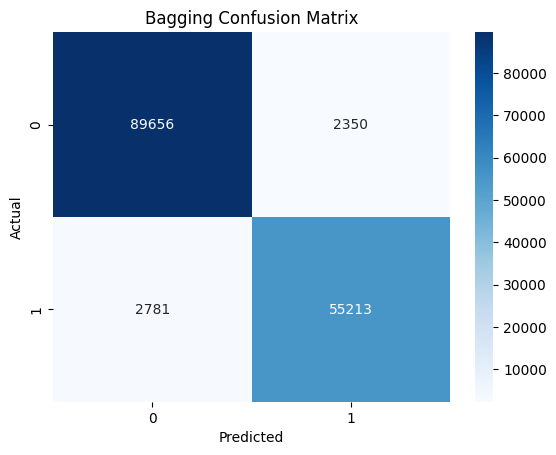


AdaBoost Performance:
Accuracy: 0.9689866666666667
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     92006
           1       0.97      0.95      0.96     57994

    accuracy                           0.97    150000
   macro avg       0.97      0.97      0.97    150000
weighted avg       0.97      0.97      0.97    150000

              precision    recall  f1-score   support

           0       0.97      0.98      0.97     92006
           1       0.97      0.95      0.96     57994

    accuracy                           0.97    150000
   macro avg       0.97      0.97      0.97    150000
weighted avg       0.97      0.97      0.97    150000



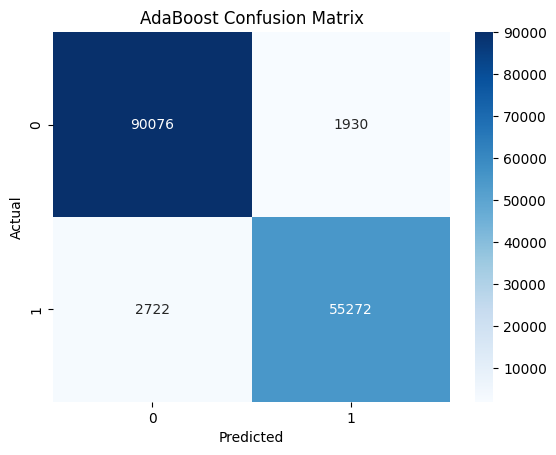


Gradient Boosting Performance:
Accuracy: 0.9727666666666667
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     92006
           1       0.96      0.97      0.96     57994

    accuracy                           0.97    150000
   macro avg       0.97      0.97      0.97    150000
weighted avg       0.97      0.97      0.97    150000



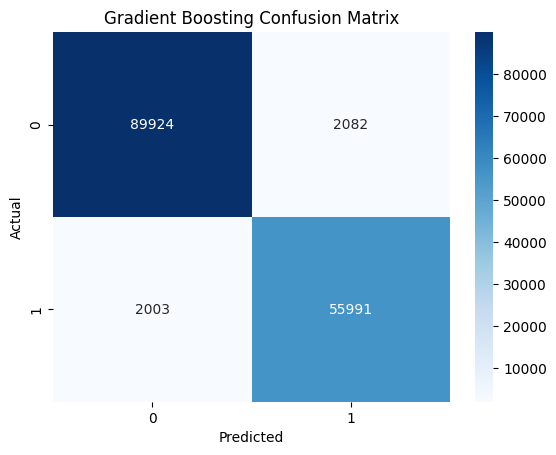


Stacking Performance:
Accuracy: 0.9732933333333333
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     92006
           1       0.97      0.96      0.97     57994

    accuracy                           0.97    150000
   macro avg       0.97      0.97      0.97    150000
weighted avg       0.97      0.97      0.97    150000



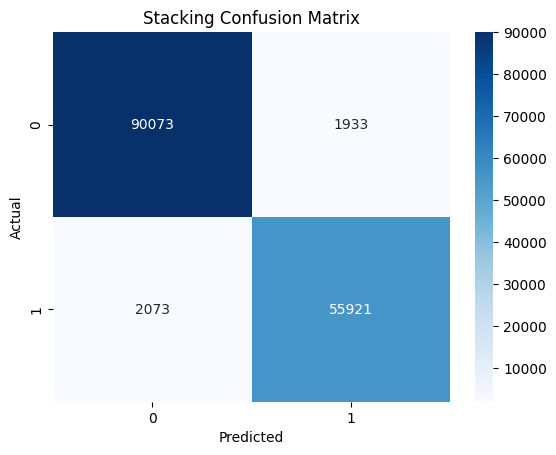

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(name, y_true, y_pred, model=None):
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    # use class_names defined near data load
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate each model
evaluate_model("Bagging", y_test, y_pred_bag)
evaluate_model("AdaBoost", y_test, y_pred_ada)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("Stacking", y_test, y_pred_stack)

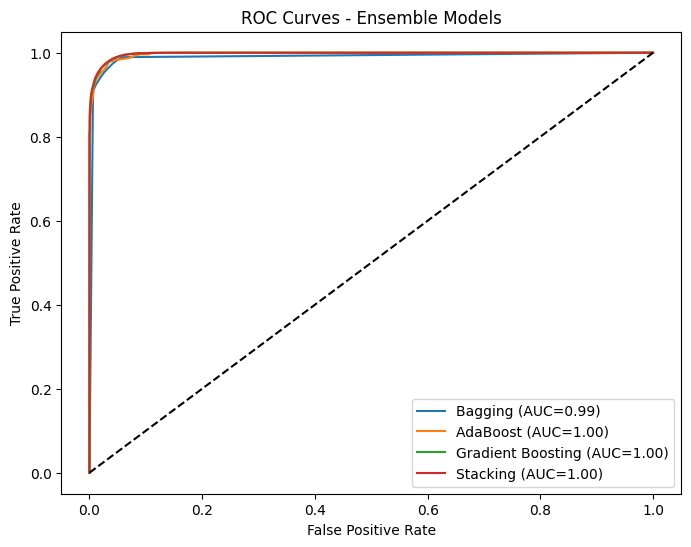

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

# Calculate ROC for each model
models = {
    "Bagging": bagging_model,
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "Stacking": stacking_model
}

for name, model in models.items():
    # Some models (e.g., SVM without probability) may not have predict_proba; try decision_function then skip if unavailable
    y_score = None
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping ROC for {name}: no probability or decision function available")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Ensemble Models")
plt.legend()
plt.show()

In [20]:
# Bagging with different number of estimators
for n in [10, 50, 100]:
    model = BaggingClassifier(
        estimator=base_tree,   
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Bagging (n_estimators={n}): Accuracy = {acc:.4f}")

# AdaBoost with different learning rates
for lr in [0.01, 0.1, 1.0]:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),  
        n_estimators=50,
        learning_rate=lr,
        random_state=42
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"AdaBoost (learning_rate={lr}): Accuracy = {acc:.4f}")


Bagging (n_estimators=10): Accuracy = 0.9658
Bagging (n_estimators=50): Accuracy = 0.9661
Bagging (n_estimators=50): Accuracy = 0.9661
Bagging (n_estimators=100): Accuracy = 0.9662
Bagging (n_estimators=100): Accuracy = 0.9662
AdaBoost (learning_rate=0.01): Accuracy = 0.9152
AdaBoost (learning_rate=0.01): Accuracy = 0.9152
AdaBoost (learning_rate=0.1): Accuracy = 0.9507
AdaBoost (learning_rate=0.1): Accuracy = 0.9507
AdaBoost (learning_rate=1.0): Accuracy = 0.9714
AdaBoost (learning_rate=1.0): Accuracy = 0.9714


In [13]:
print("\n--- Summary ---")
print("Bagging: reduces variance, stable predictions.")
print("Boosting: reduces bias, improves weak learners sequentially.")
print("Stacking: combines diverse models, often best performance.")
print("Trade-offs: Bagging is parallel & faster, Boosting can overfit if too many learners, Stacking is powerful but complex.")


--- Summary ---
Bagging: reduces variance, stable predictions.
Boosting: reduces bias, improves weak learners sequentially.
Stacking: combines diverse models, often best performance.
Trade-offs: Bagging is parallel & faster, Boosting can overfit if too many learners, Stacking is powerful but complex.
